# TRACED — Usage Examples

**TRACED** (Trend-Adaptive Classification with Ellipsoidal Disambiguation) is a single-pass online classifier that learns one sample at a time without storing training data.

Each class is represented by a collection of **hyperellipsoid neurons** that grow and merge incrementally.

### Key Hyperparameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `method` | `'overlap-outside'` | Region to resolve: `'overlap'`, `'outside'`, or `'overlap-outside'` |
| `reduce_dims` | `0` | Number of PCA dimensions to drop during overlap resolution (0 = disabled) |
| `distance_metric` | `'boundary'` | Distance measure: `'boundary'` or `'center'` |
| `N0` | `3` | Minimum samples a neuron must accumulate before voting in `predict` |
| `delta` | `2` | Distance-threshold multiplier when creating a new neuron |
| `r` | `√(2π)` | Ellipsoid scale factor |
| `alpha` | `0` | Displacement smoothing (0 = no memory) |
| `beta` | `0` | Expansion smoothing (0 = no memory) |
| `width_parameter` | `1` | Blend between PCA-width and shift-width |
| `norm` | `2` | Minkowski norm (2 = Euclidean) |
| `threshold` | `15` | Angle threshold for pairing PCA axes (degrees) |

In [49]:
import numpy as np
from sklearn.datasets import load_iris, load_digits, make_classification
from sklearn.metrics import accuracy_score
from sklearn.base import clone
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from spdal import TRACED

## 1. Basic Batch Usage

Learn all training data in a single call to `partial_fit`, then predict on the test set.

In [50]:
X, y = load_iris(return_X_y=True)
X_train, X_test = X[:120], X[120:]
y_train, y_test = y[:120], y[120:]

clf = TRACED(alpha=0.2)
clf.partial_fit(X_train, y_train, classes=np.unique(y))
y_pred = clf.predict(X_test)

print(f"Classes learned : {clf.classes_}")
print(f"Neurons created : {len(clf.neuron_list)}")
print(f"Accuracy        : {accuracy_score(y_test, y_pred):.2%}")
print(f"Predictions     : {y_pred.tolist()}")

Classes learned : [0 1 2]
Neurons created : 7
Accuracy        : 100.00%
Predictions     : [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


## 2. Neuron Inspection

`clf.neuron_list` is a `list[dict]` — each neuron stores `center`, `width`, `cov`, `eig_component`, `n`, `displacement`, and `expansion`.

In [51]:
print(f"{'#':<4} {'class':<7} {'n':>5}   {'center':^32}   {'width':^32}")
print("-" * 85)
for i, n in enumerate(clf.neuron_list):
    center_str = str(np.round(n['center'], 2))
    width_str  = str(np.round(n['width'],  3))
    print(f"{i:<4} {str(n['y']):<7} {n['n']:>5}   {center_str:<32}   {width_str:<32}")

#    class       n                center                             width              
-------------------------------------------------------------------------------------
0    0          46   [5.   3.43 1.48 0.25]              [0.995 0.459 0.381 0.237]       
1    0           2   [4.4  2.65 1.2  0.2 ]              [0.979 0.    0.    0.   ]       
2    0           2   [5.75 4.2  1.35 0.3 ]              [0.686 0.    0.    0.   ]       
3    1          44   [6.04 2.82 4.38 1.37]              [1.359 0.681 0.57  0.25 ]       
4    1           6   [5.2  2.37 3.38 1.02]              [0.848 0.568 0.184 0.044]       
5    2          19   [6.65 2.94 5.72 2.06]              [2.14  0.911 0.543 0.341]       
6    2           1   [4.9 2.5 4.5 1.7]                  [0. 0. 0. 0.]                   


## 3. Incremental Learning — 10 Chunks (Phishing Dataset, Prequential)

Uses **test-then-train** (prequential) evaluation: each chunk is first predicted (test), then used to update the model (train).
**Phishing** (from `river`): 1,250 samples · 9 features · 2 classes (phishing vs. legitimate)

Data is split into 10 equal chunks of 125 samples. **Chunk 1** is used for warm-up (train only).

> Install river: `pip install -e ".[experiments]"`

In [52]:
from river.datasets import Phishing

data = Phishing()
X_ph = np.array([np.array(list(s[0].values())) for s in data])
y_ph = np.array([int(s[1]) for s in data])
classes_ph = np.unique(y_ph)

N_CHUNKS_PH = 10
CHUNK_SIZE_PH = len(X_ph) // N_CHUNKS_PH  # 125 per chunk
chunks = [(X_ph[i*CHUNK_SIZE_PH:(i+1)*CHUNK_SIZE_PH],
           y_ph[i*CHUNK_SIZE_PH:(i+1)*CHUNK_SIZE_PH]) for i in range(N_CHUNKS_PH)]

print(f"Dataset: {X_ph.shape[0]} samples, {X_ph.shape[1]} features, classes={classes_ph}")
print(f"Protocol: prequential test-then-train, {N_CHUNKS_PH} chunks × {CHUNK_SIZE_PH} samples\n")

clf_ph = TRACED(method="overlap-outside", reduce_dims=1)

print(f"{'Chunk':>7}  {'Neurons':>7}  {'Accuracy':>9}  {'Cum Acc':>9}  {'Overlap':>8}  {'Outside':>8}")
print("-" * 62)
chunk_accs_ph = []
cum_correct_ph = 0
cum_total_ph   = 0

for i, (Xc, yc) in enumerate(chunks):
    if i == 0:
        clf_ph.partial_fit(Xc, yc, classes=classes_ph)
        chunk_accs_ph.append(None)
        print(f"{i+1:>5}/10  {len(clf_ph.neuron_list):>7}  {'(init)':>9}  {'(init)':>9}"
              f"  {clf_ph.count_overlap:>8}  {clf_ph.count_outside:>8}")
        continue

    # TEST first
    y_pred = clf_ph.predict(Xc)
    acc = accuracy_score(yc, y_pred)
    cum_correct_ph += np.sum(y_pred == yc)
    cum_total_ph   += len(yc)
    cum_acc = cum_correct_ph / cum_total_ph
    chunk_accs_ph.append(acc)

    # TRAIN after
    clf_ph.partial_fit(Xc, yc, classes=classes_ph)

    print(f"{i+1:>5}/10  {len(clf_ph.neuron_list):>7}  {acc:>9.2%}  {cum_acc:>9.2%}"
          f"  {clf_ph.count_overlap:>8}  {clf_ph.count_outside:>8}")

Dataset: 1250 samples, 9 features, classes=[0 1]
Protocol: prequential test-then-train, 10 chunks × 125 samples

  Chunk  Neurons   Accuracy    Cum Acc   Overlap   Outside
--------------------------------------------------------------
    1/10        2     (init)     (init)         0         0
    2/10        2     86.40%     86.40%         0       103
    3/10        2     90.40%     88.40%         0       193
    4/10        2     86.40%     87.73%         0       280
    5/10        2     90.40%     88.40%         0       373
    6/10        2     93.60%     89.44%         0       463
    7/10        2     91.20%     89.73%         0       541
    8/10        2     88.80%     89.60%         0       629
    9/10        2     92.80%     90.00%         0       710
   10/10        2     88.80%     89.87%         0       793


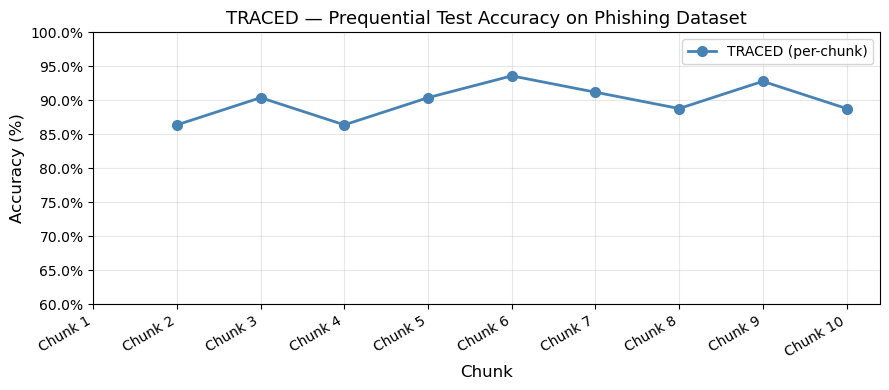

In [53]:
fig, ax = plt.subplots(figsize=(9, 4))
valid_chunks_ph = [i+1 for i, a in enumerate(chunk_accs_ph) if a is not None]
valid_accs_ph   = [a * 100 for a in chunk_accs_ph if a is not None]
ax.plot(valid_chunks_ph, valid_accs_ph,
        marker='o', linewidth=2, markersize=7, color='steelblue', label='TRACED (per-chunk)')
ax.set_xlabel("Chunk", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("TRACED — Prequential Test Accuracy on Phishing Dataset", fontsize=13)
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f"Chunk {i}" for i in range(1, 11)], rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_ylim(60, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
X_s, y_s = make_classification(n_samples=1000, n_features=8, random_state=0)
chunks_s = [(X_s[i:i+100], y_s[i:i+100]) for i in range(0, 1000, 100)]

clf_s = TRACED(method="overlap-outside", reduce_dims=1)
stream_accs    = []
cum_correct_s  = 0
cum_total_s    = 0

print(f"{'Chunk':>7}  {'Neurons':>7}  {'Accuracy':>9}  {'Cum Acc':>9}  {'Overlap':>8}  {'Outside':>8}")
print("-" * 62)

for i, (Xc, yc) in enumerate(chunks_s):
    if i == 0:
        clf_s.partial_fit(Xc, yc, classes=np.array([0, 1]))
        stream_accs.append(None)
        print(f"{i+1:>5}/10  {len(clf_s.neuron_list):>7}  {'(init)':>9}  {'(init)':>9}"
              f"  {clf_s.count_overlap:>8}  {clf_s.count_outside:>8}")
        continue

    # TEST first
    y_pred = clf_s.predict(Xc)
    acc = np.mean(y_pred == yc)
    cum_correct_s += np.sum(y_pred == yc)
    cum_total_s   += len(yc)
    stream_accs.append(acc)

    # TRAIN after
    clf_s.partial_fit(Xc, yc, classes=np.array([0, 1]))

    print(f"{i+1:>5}/10  {len(clf_s.neuron_list):>7}  {acc:>9.2%}  {cum_correct_s/cum_total_s:>9.2%}"
          f"  {clf_s.count_overlap:>8}  {clf_s.count_outside:>8}")

  Chunk  Neurons   Accuracy    Cum Acc   Overlap   Outside
--------------------------------------------------------------
    1/10        2     (init)     (init)         0         0
    2/10        2     89.00%     89.00%         0        49
    3/10        2     92.00%     90.50%         2        89
    4/10        2     96.00%     92.33%         3       134
    5/10        2     93.00%     92.50%         5       172
    6/10        2     97.00%     93.40%         7       204
    7/10        2     96.00%     93.83%         9       231
    8/10        2     95.00%     94.00%        11       270
    9/10        2     92.00%     93.75%        18       303
   10/10        2     95.00%     93.89%        22       334


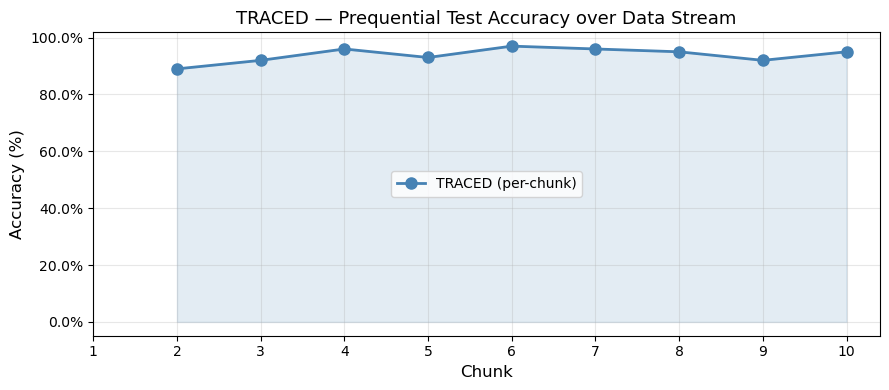

In [74]:
fig, ax = plt.subplots(figsize=(9, 4))
valid_chunks_s = [i+1 for i, a in enumerate(stream_accs) if a is not None]
valid_accs_s   = [a * 100 for a in stream_accs if a is not None]
ax.plot(valid_chunks_s, valid_accs_s,
        marker='o', linewidth=2, markersize=8, color='steelblue', label='TRACED (per-chunk)')
ax.fill_between(valid_chunks_s, valid_accs_s, alpha=0.15, color='steelblue')
ax.set_xlabel("Chunk", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("TRACED — Prequential Test Accuracy over Data Stream", fontsize=13)
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()